# 3D Homogeneous SSR (HYPRE + Profiler)

## Notes Before Running
- Activate local environment: `source setup/activate_optimized_octave.sh`
- In Jupyter, select `Octave (local-rsb)` kernel.
- This notebook follows the same workflow style as the COMSOL notebook, adapted to the homogeneous SSR benchmark.

In [1]:
%plot -f png -r 600
% Load sparsersb for multithreaded sparse matrix-vector products
pkg load sparsersb;

% Configure toolkit for both GUI and headless Jupyter environments.
try
    graphics_toolkit('qt');
catch
    graphics_toolkit('gnuplot');
end
set(0, 'defaultfigurevisible', 'off');

fprintf('Working directory: %s\n', pwd);
fprintf('Graphics toolkit: %s\n', graphics_toolkit());


Working directory: /home/beremi/repos/slope_stability/slope_stability
Graphics toolkit: qt


## 1) Main Input Data

In [2]:
% elem_type - type of finite elements; available choices: 'P2'
elem_type = 'P2';

% Davis_type - choice of Davis' approach; available choices: 'A','B','C'
Davis_type = 'B';

% Mechanical parameters per subdomain:
% [c0, phi, psi, young, poisson, gamma_sat, gamma_unsat]
mat_props = [6, 45, 0, 40000, 0.3, 20, 20];

% Mesh file (benchmark family)
%   SSR_homo_uni.h5:    25415 / 15770
%   SSR_homo_ada_L1.h5: 25591 / 16615
%   SSR_homo_ada_L2.h5: 48449 / 32985
%   SSR_homo_ada_L3.h5: 91659 / 63968
%   SSR_homo_ada_L4.h5: 174902 / 124300
%   SSR_homo_ada_L5.h5: 336774 / 242716
file_path = 'meshes/SSR_homo_ada_L1.h5';


## 2) Reference Element Data and Mesh Load

In [3]:
% quadrature points and weights for volume integration
[Xi, WF] = ASSEMBLY.quadrature_volume_3D(elem_type);

% local basis functions and their derivatives
[HatP, DHatP1, DHatP2, DHatP3] = ASSEMBLY.local_basis_volume_3D(elem_type, Xi);

switch(elem_type)
    case 'P1'
        error('Prepared meshes are only for P2 elements.');
    case 'P2'
        [coord, elem, surf, Q, ~] = MESH.load_mesh_P2(file_path);
        fprintf('P2 elements: homogeneous slope\n');
    otherwise
        error('Bad choice of element type.');
end

% Same default as the COMSOL-style notebook: apply reordering for solver performance.
[coord, elem, surf, Q] = MESH.reorder_mesh(coord, elem, surf, Q);

% Mesh statistics
n_n = size(coord,2);
n_unknown = length(coord(Q));
n_e = size(elem,2);
n_q = length(WF);
n_int = n_e * n_q;

fprintf('\nMesh data:');
fprintf('  number of nodes =%d ', n_n);
fprintf('  number of unknowns =%d ', n_unknown);
fprintf('  number of elements =%d ', n_e);
fprintf('  number of integration points =%d ', n_int);
fprintf('\n');

% Homogeneous identifier
material_identifier = zeros(1, n_e);


P2 elements: homogeneous slope
  Mesh reordering (symrcm): bandwidth 20868 -> 25569 (0.8x reduction)

Mesh data:  number of nodes =25591   number of unknowns =71947   number of elements =16615   number of integration points =182765 


### Mesh Preview

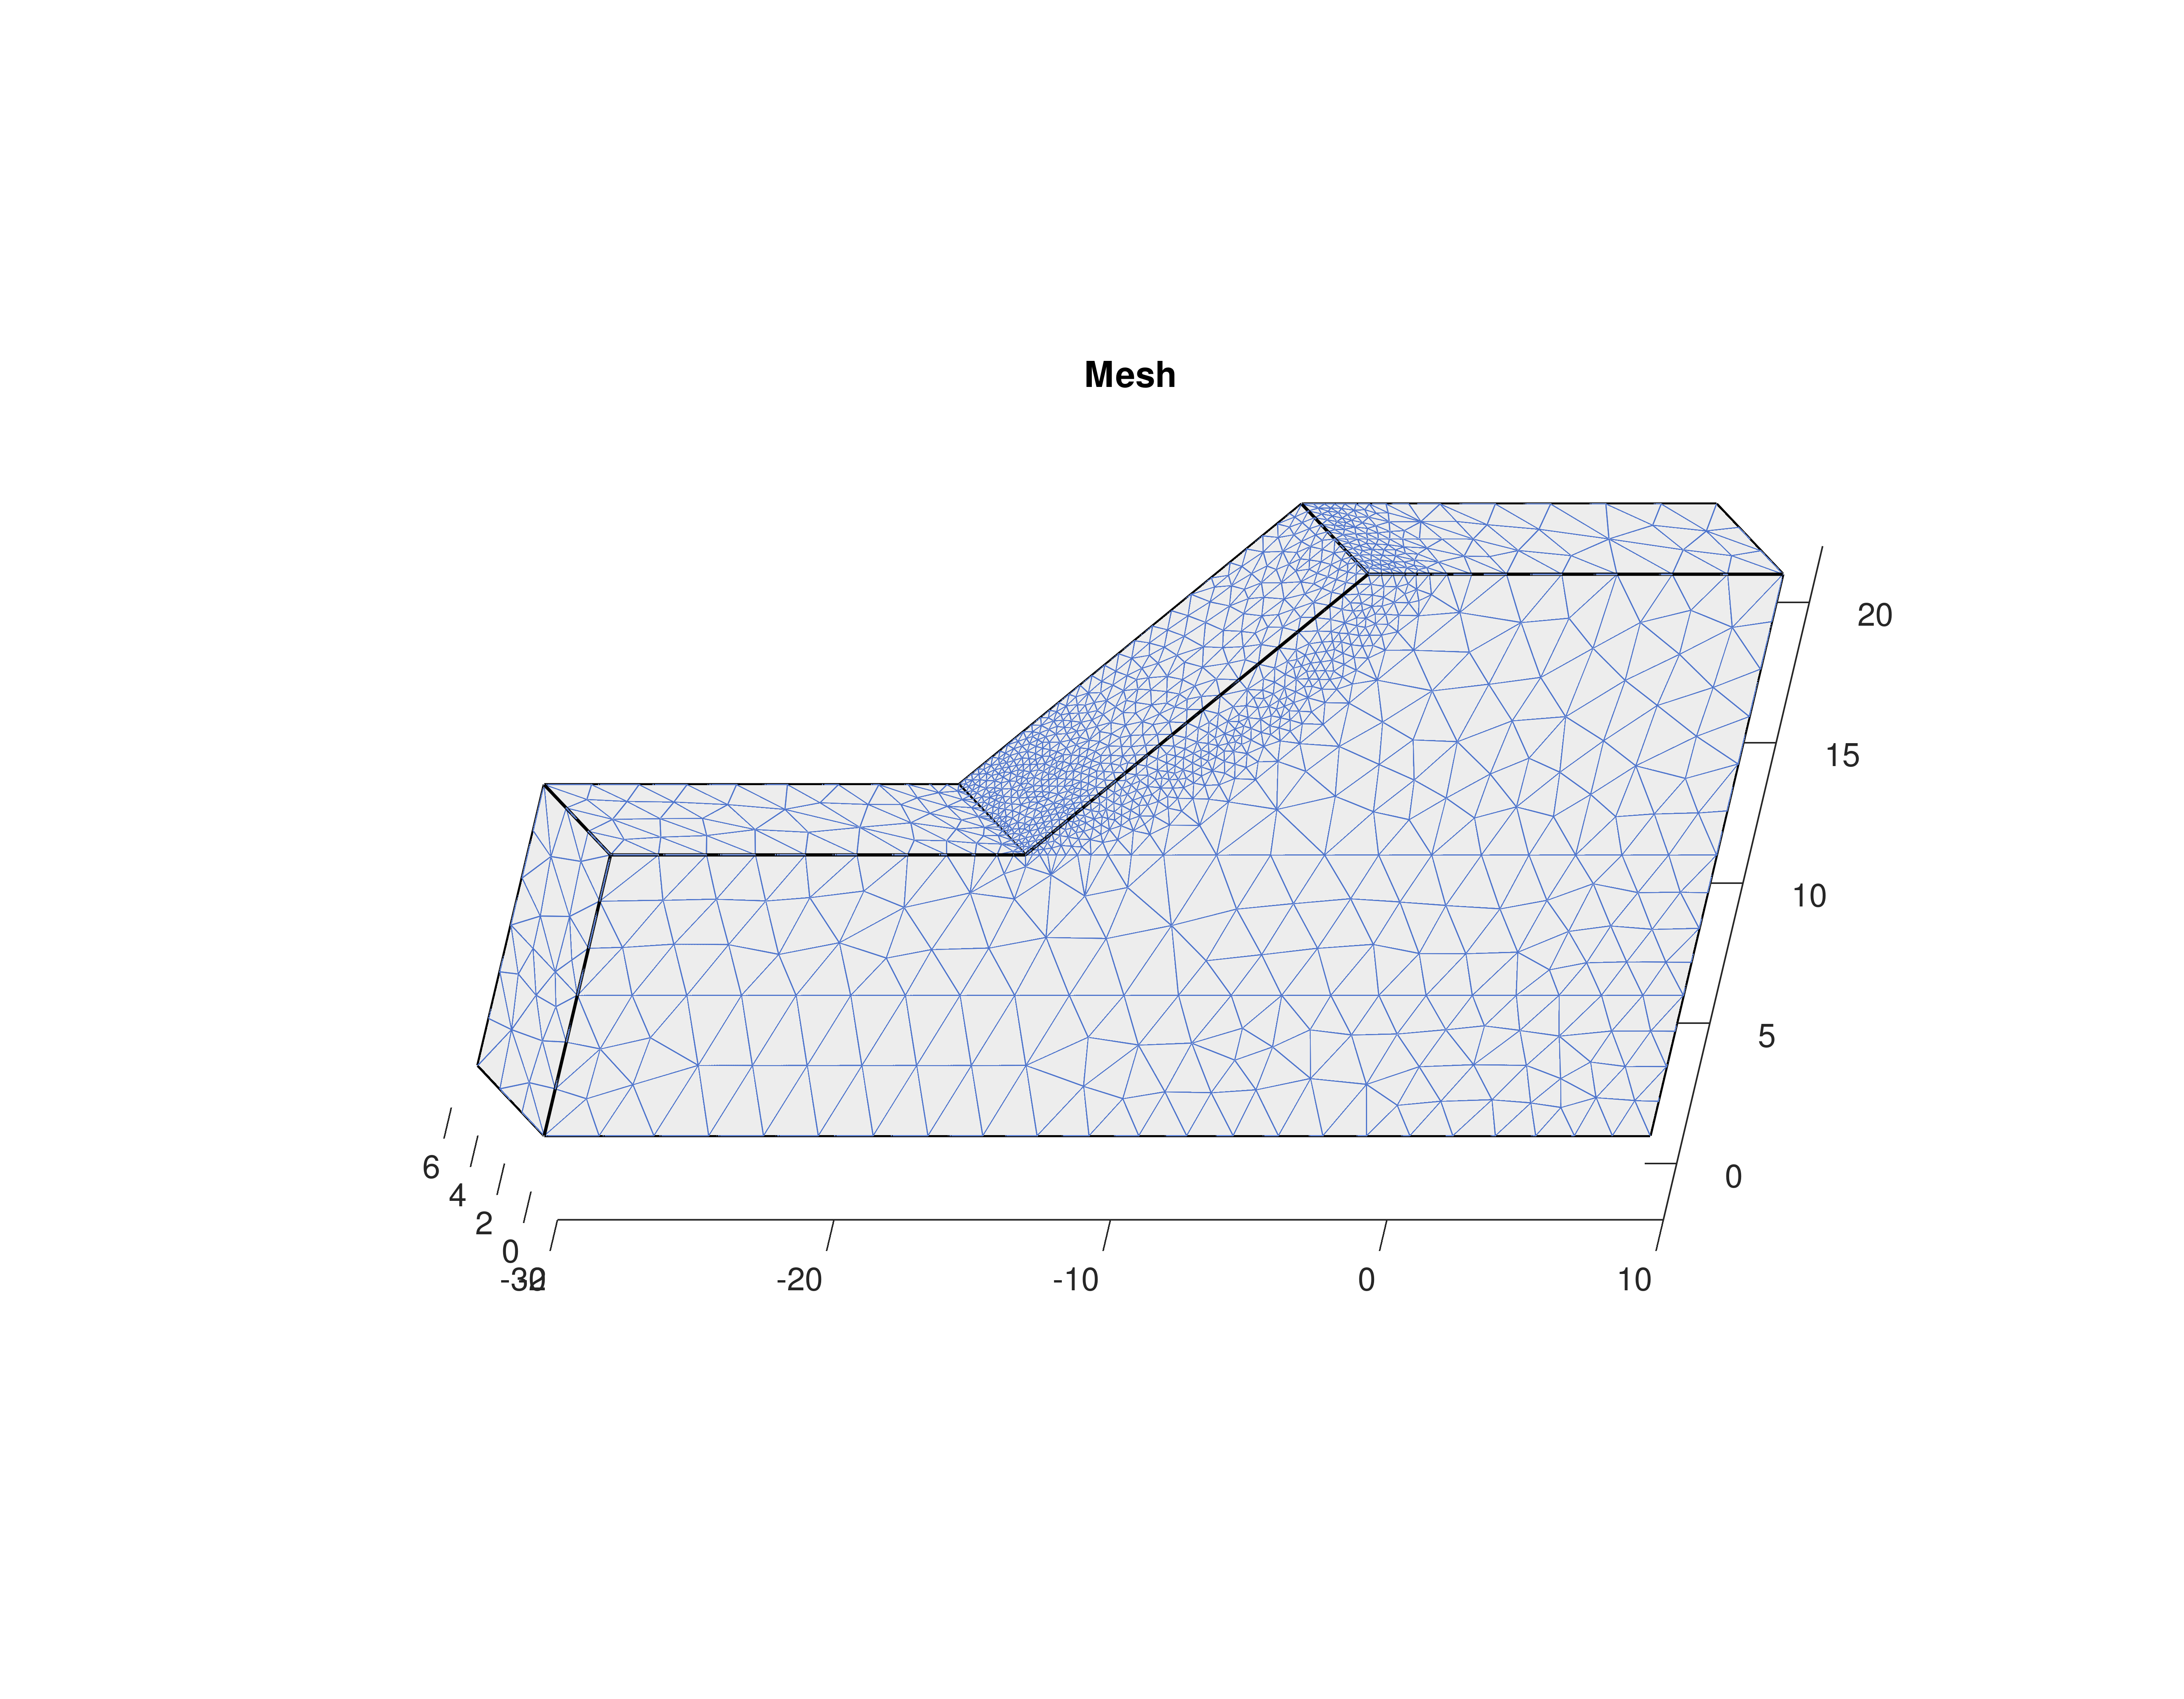

In [4]:
% Use explicit COMSOL camera preset for visual parity.
plotter = VIZ.SolutionPlotter(coord, elem, surf, 'comsol');
plotter.plot_mesh();
drawnow;


## 3) Mechanical Material Fields and Assembly

In [5]:
fields = {'c0', 'phi', 'psi', 'young', 'poisson', 'gamma_sat', 'gamma_unsat'};
materials = cellfun(@(x) cell2struct(num2cell(x), fields, 2), num2cell(mat_props, 2), 'UniformOutput', false);

% Homogeneous benchmark uses fully saturated body.
saturation = true(1, n_int);

[c0, phi, psi, shear, bulk, lame, gamma] = ...
    ASSEMBLY.heterogenous_materials(material_identifier, saturation, n_q, materials);

% Elastic stiffness matrix + element-level derivative data (DPhi1/2/3)
[K_elast, B, WEIGHT, DPhi1_out, DPhi2_out, DPhi3_out] = ASSEMBLY.elastic_stiffness_matrix_3D(
    elem, coord, shear, bulk, DHatP1, DHatP2, DHatP3, WF);

% Gravity-only volume force
f_V_int = [zeros(1, n_int); -gamma; zeros(1, n_int)];
f_V = ASSEMBLY.vector_volume_3D(elem, coord, f_V_int, HatP, WEIGHT);


In [6]:
% Attach strain data to the plotter for later visualisation.
plotter.set_strain_data(B, Xi);


## 4) Continuation, Newton, and Linear Solver Parameters

In [7]:
% Continuation parameters
lambda_init = 0.9;
d_lambda_init = 0.1;
d_lambda_min = 1e-3;
d_lambda_diff_scaled_min = 0.001;
omega_max_stop = 3000;
step_max = 100;

% Newton parameters
it_newt_max = 100;
it_damp_max = 10;
tol = 1e-4;
r_min = 1e-4;

% Linear solver settings (HYPRE BoomerAMG + DFGMRES)
% agmg folder is baked into LINEAR_SOLVERS.set_linear_solver
solver_type = 'DFGMRES_HYPRE_BOOMERAMG';

linear_solver_tolerance = 1e-1;
linear_solver_maxit = 100;
deflation_basis_tolerance = 1e-3;
linear_solver_printing = 0;

boomeramg_opts = struct('threads', 16, 'print_level', 0, ...
    'use_as_preconditioner', true);

linear_system_solver = LINEAR_SOLVERS.set_linear_solver(solver_type, ...
    linear_solver_tolerance, linear_solver_maxit, deflation_basis_tolerance, ...
    linear_solver_printing, Q, coord, boomeramg_opts);

% Constitutive model object
n_strain = 6;
constitutive_matrix_builder = CONSTITUTIVE_PROBLEM.CONSTITUTIVE(
    B, c0, phi, psi, Davis_type, shear, bulk, lame, WEIGHT, n_strain, n_int, 3);

% Provide element geometry for fast element-level tangent assembly.
constitutive_matrix_builder.set_element_data(elem, DPhi1_out, DPhi2_out, DPhi3_out);

% Shared profiler
profiler = PROFILING.Profiler();
constitutive_matrix_builder.profiler = profiler;
linear_system_solver.profiler = profiler;


Element data set: n_p=10, n_e=16615, n_q=11, mex=1


## 5) Run SSR Continuation (Indirect Only)

In [8]:
direct_on = 0;
indirect_on = 1;

if direct_on
    fprintf('\n Direct continuation method\n');
    tic;
    [U2, lambda_hist2, omega_hist2, Umax_hist2] = CONTINUATION.SSR_direct_continuation(...
        lambda_init, d_lambda_init, d_lambda_min, d_lambda_diff_scaled_min, step_max, ...
        it_newt_max, it_damp_max, tol, r_min, K_elast, Q, f_V, ...
        constitutive_matrix_builder, linear_system_solver.copy());
    time_run = toc;
    fprintf('Running_time = %f \n', time_run);
end

if indirect_on
    fprintf('\n Indirect continuation method\n');
    tic;
    [U3, lambda_hist3, omega_hist3, Umax_hist3, stats] = CONTINUATION.SSR_indirect_continuation(...
        lambda_init, d_lambda_init, d_lambda_min, d_lambda_diff_scaled_min, step_max, ...
        omega_max_stop, it_newt_max, it_damp_max, tol, r_min, K_elast, Q, f_V, ...
        constitutive_matrix_builder, linear_system_solver.copy());
    time_run = toc;
    fprintf('Running_time = %f \n', time_run);
end

if ~isempty(strfind(upper(char(solver_type)), 'BOOMERAMG'))
    LINEAR_SOLVERS.hypre_boomeramg_clear();
end



 Indirect continuation method
Initialising K_r(Q,Q) sparse pattern ... done  (8.9 s, n_Q = 71947, nnz = 5536583)
Building element scatter map ... done  (0.7 s, n_local_dof=30, map_size=120 MB)
Init step 1: lambda=0.9
newton summary: status=converged, it=10, rel_resid=1.428813e-05, lin_it_total=45, wall_time=3.88 s
   lambda_init = 0.9, d_lambda_init = 0.1, omega_init = 2201.8807
Init step 2: searching lambda2 from lambda1=0.9
newton summary: status=converged, it=9, rel_resid=9.172117e-05, lin_it_total=36, wall_time=5.46 s
   lambda1 = 0.9, lambda2 = 1, d_lambda = 0.1, omega1 = 2201.8807, omega2 = 2204.5328, d_omega = 2.6521
Step 3: omega_target=2207.18, d_omega=2.65209
newton_ind_SSR summary: status=converged, it=6, rel_resid=5.399138e-05, lin_it_total=[W:12,V:27], wall_time=2.88 s
  accepted: lambda=1.05277, d_lambda=0.05277, d_lambda_diff_scaled=0.10554, omega=2207.18, d_omega=2.65209, U_max=0.0855922
Step 4: omega_target=2212.49, d_omega=5.30418
newton_ind_SSR summary: status=conve

## Profiler Summary

In [9]:
profiler.print_summary();



  Profiler Summary
  Time      %       Calls  Operation
  --------- ------ ------  ------------------------------
     22.51s  31.1%    239  DFGMRES.solve
     13.66s  18.9%    116  DFGMRES.update_preconditioner
     11.78s  16.3%    449  CONSTITUTIVE.stress
      7.36s  10.2%    496  CONSTITUTIVE.reduction
      6.61s   9.1%    584  CONSTITUTIVE.build_F
      4.11s   5.7%    135  CONSTITUTIVE.stress_tangent
      2.76s   3.8%    128  CONSTITUTIVE.build_K_tangent_QQ_vals
      2.08s   2.9%    128  DFGMRES.A_orthogonalize
      1.45s   2.0%     12  DFGMRES.setup_preconditioner
      0.13s   0.2%    223  DFGMRES.expand_deflation_basis
  --------- ------ ------  ------------------------------
     72.45s                TOTAL

  Sub-profile: DFGMRES.solve  (22.51s total, 239 calls)
  --------- ------ ------  ------------------------------
     14.97s  66.5%    180  precond_apply
      2.71s  12.0%    180  deflation_project
      2.51s  11.2%    239  init
      0.85s   3.8%    180  arnoldi

## 6) Mechanical Results and Convergence

Notebook workflow completed.


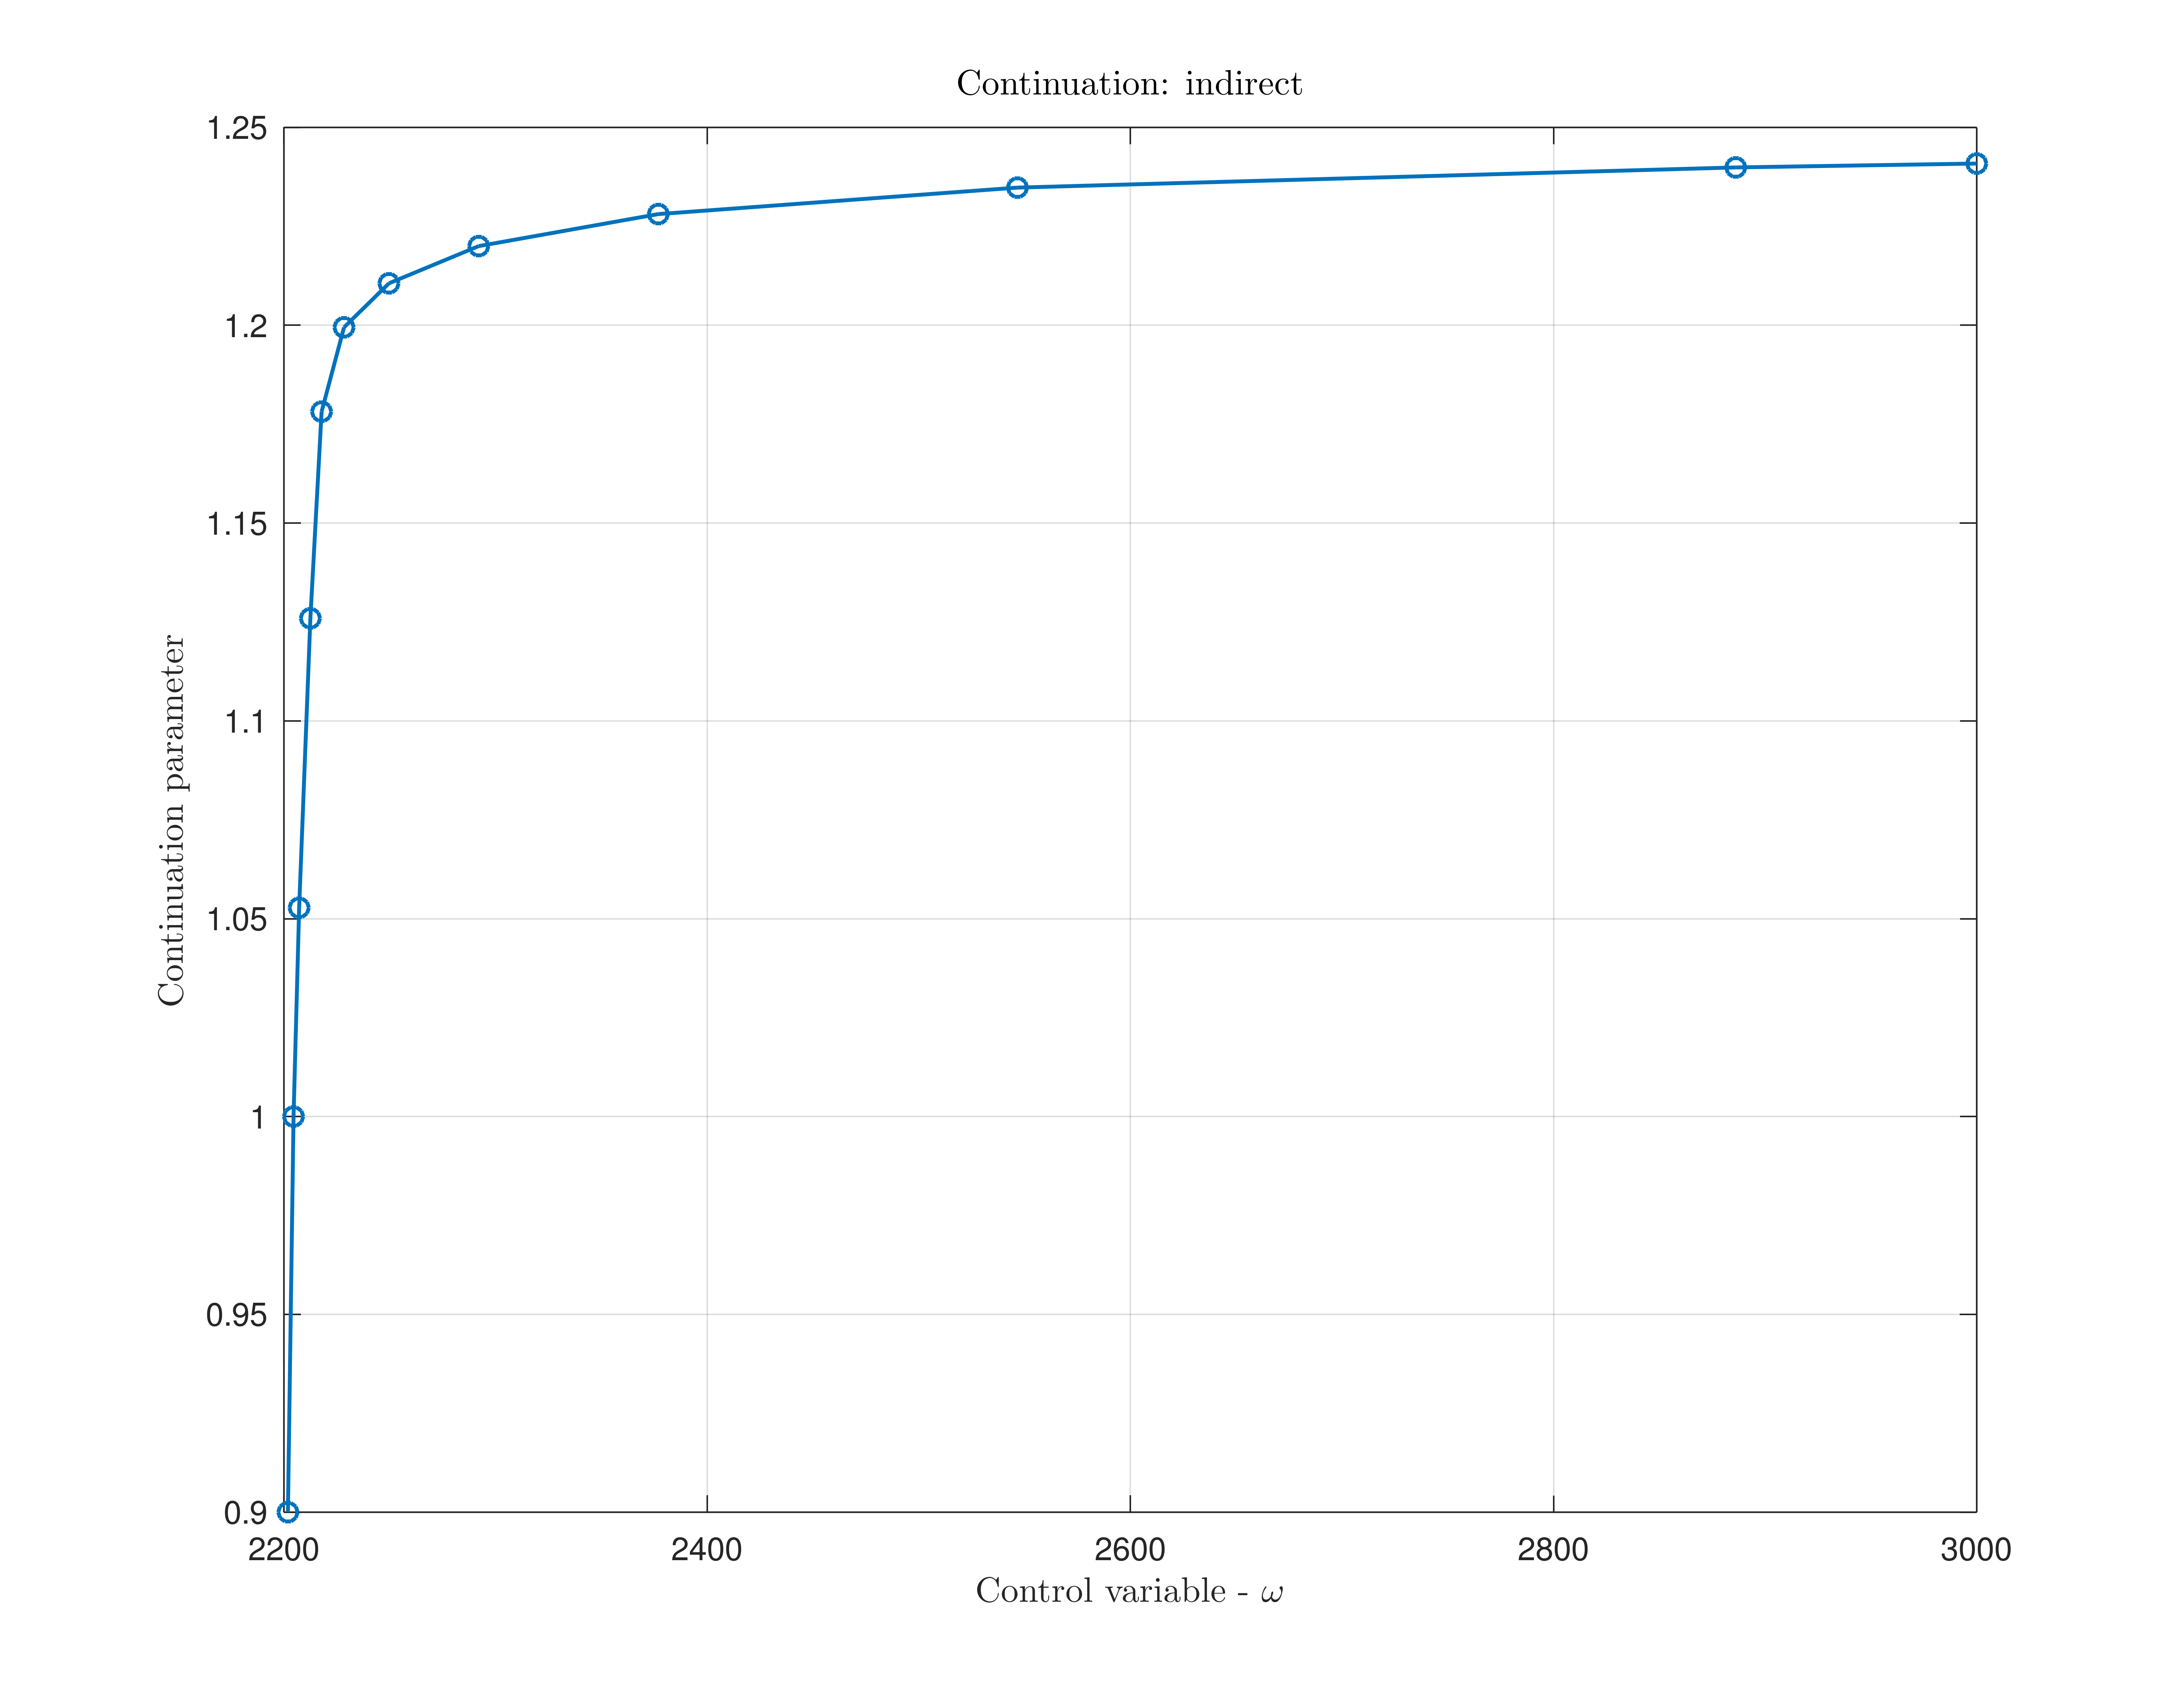

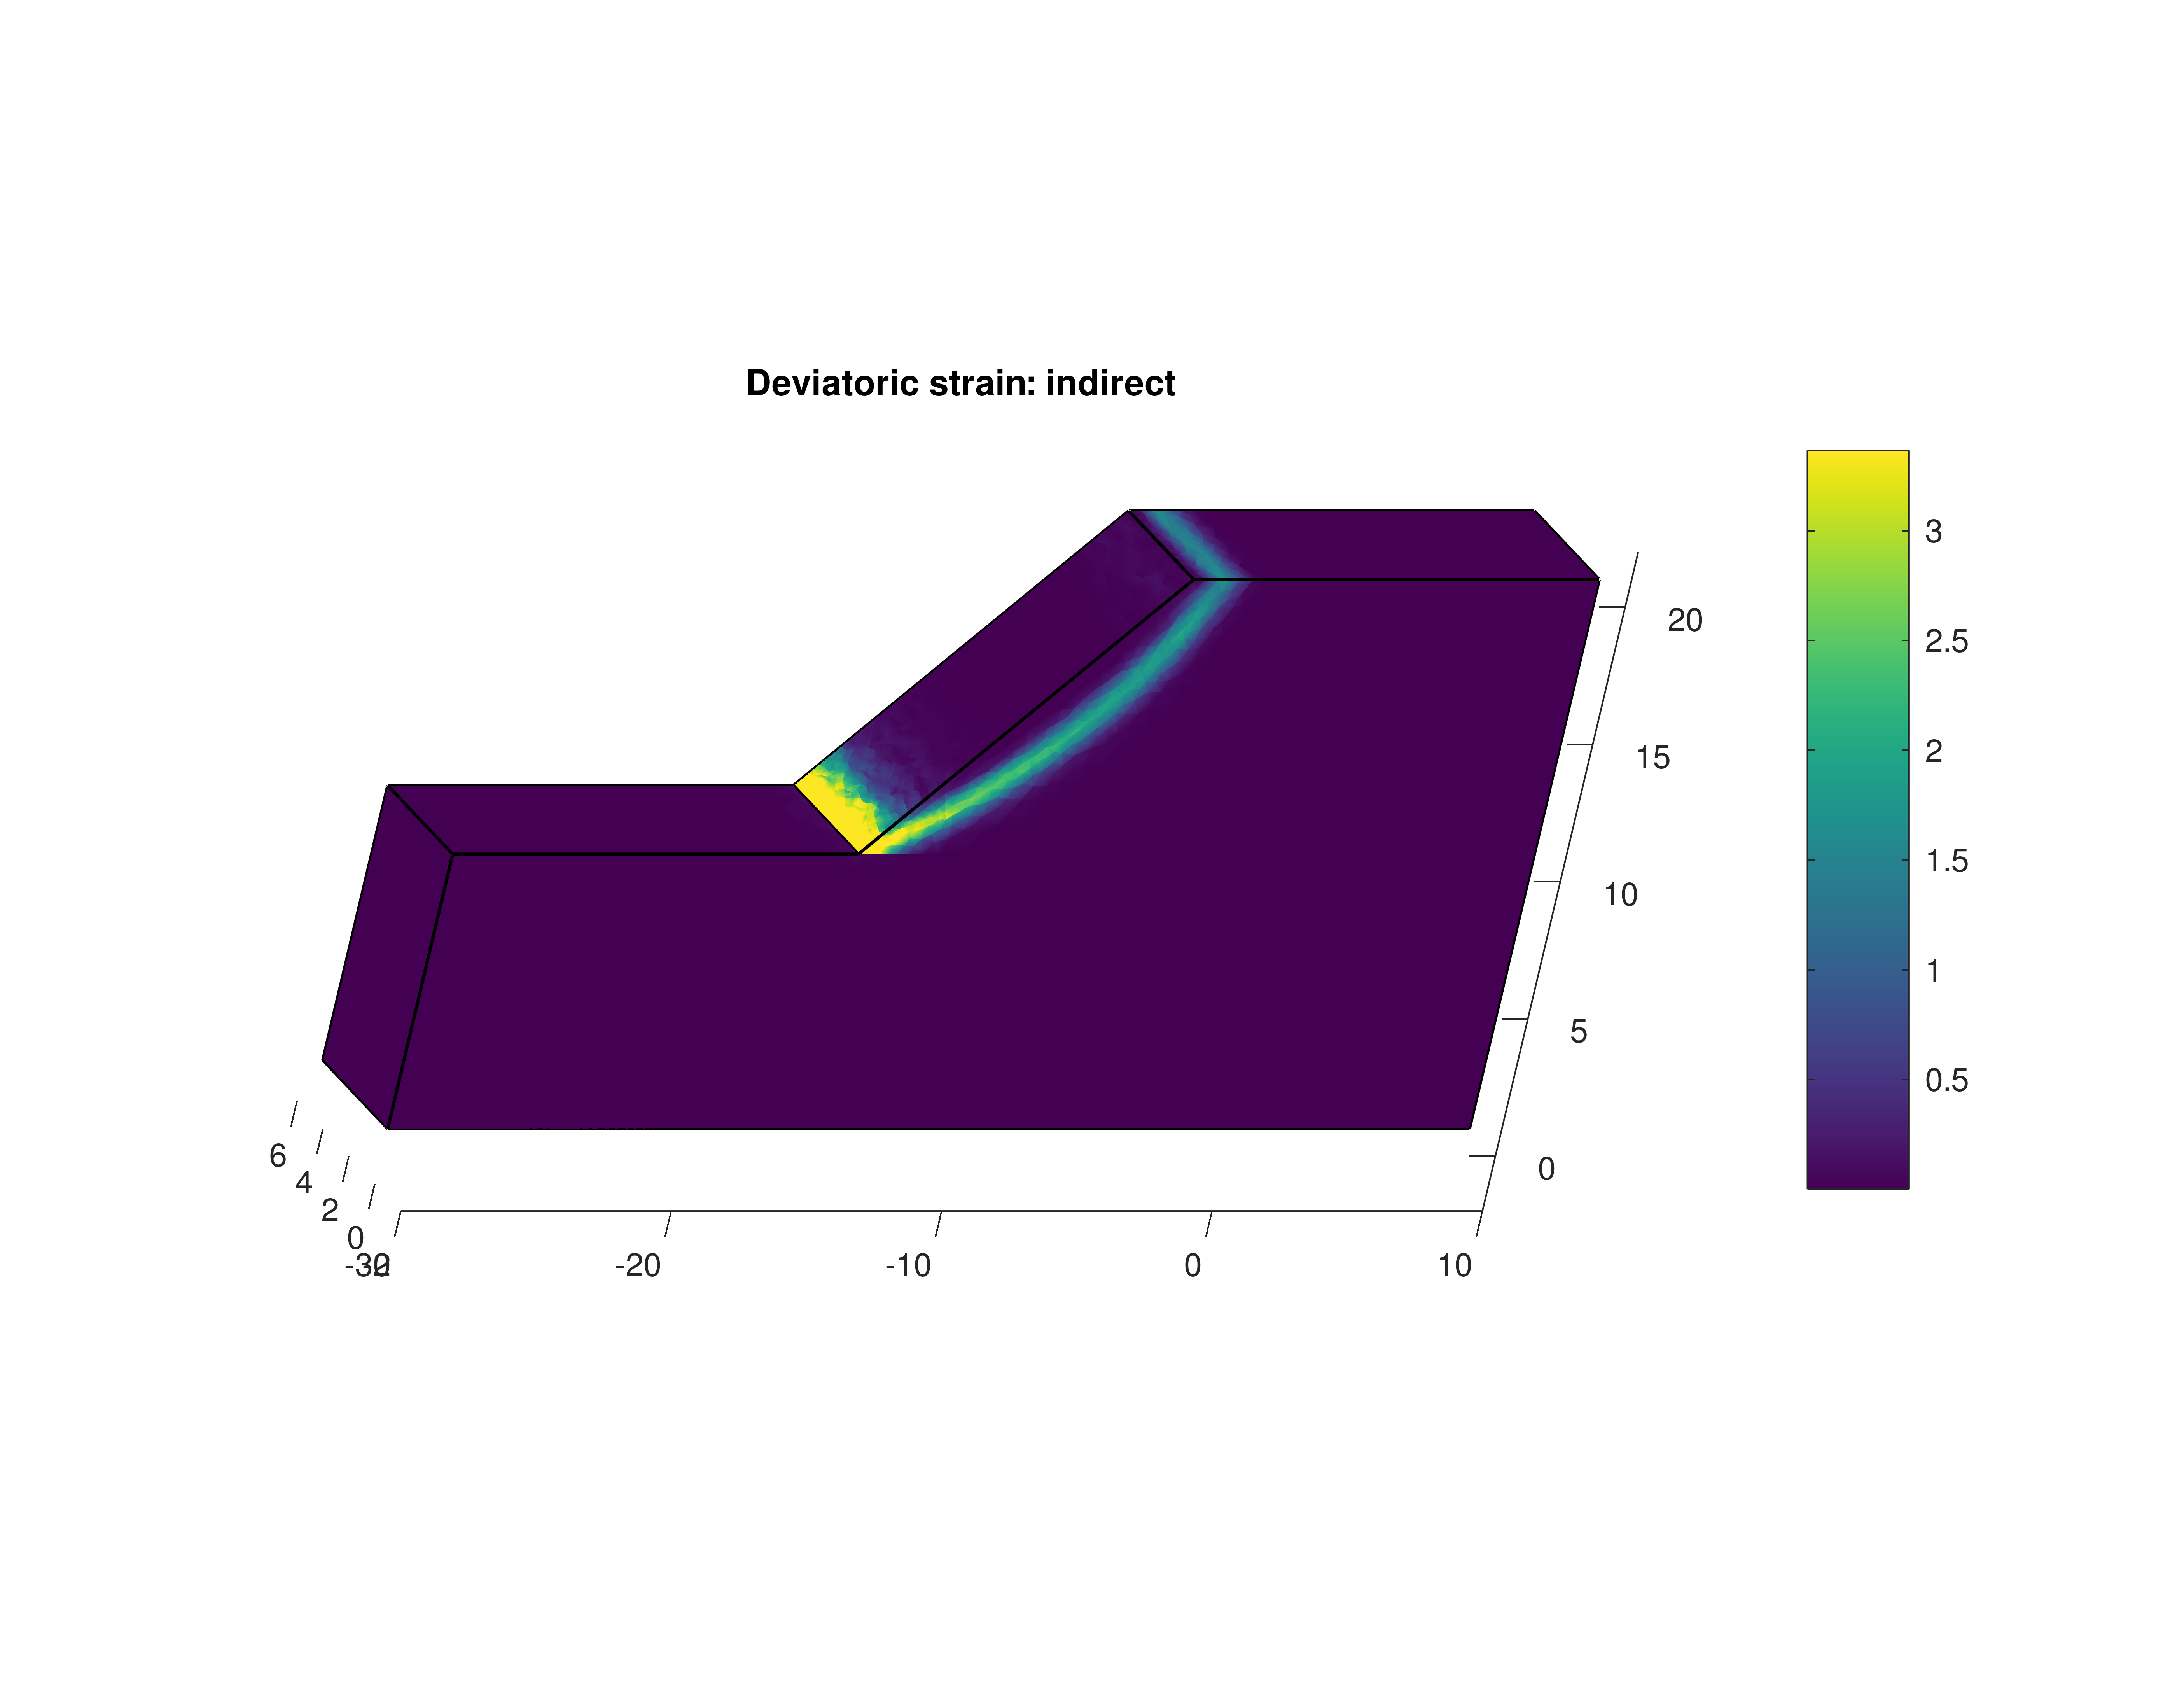

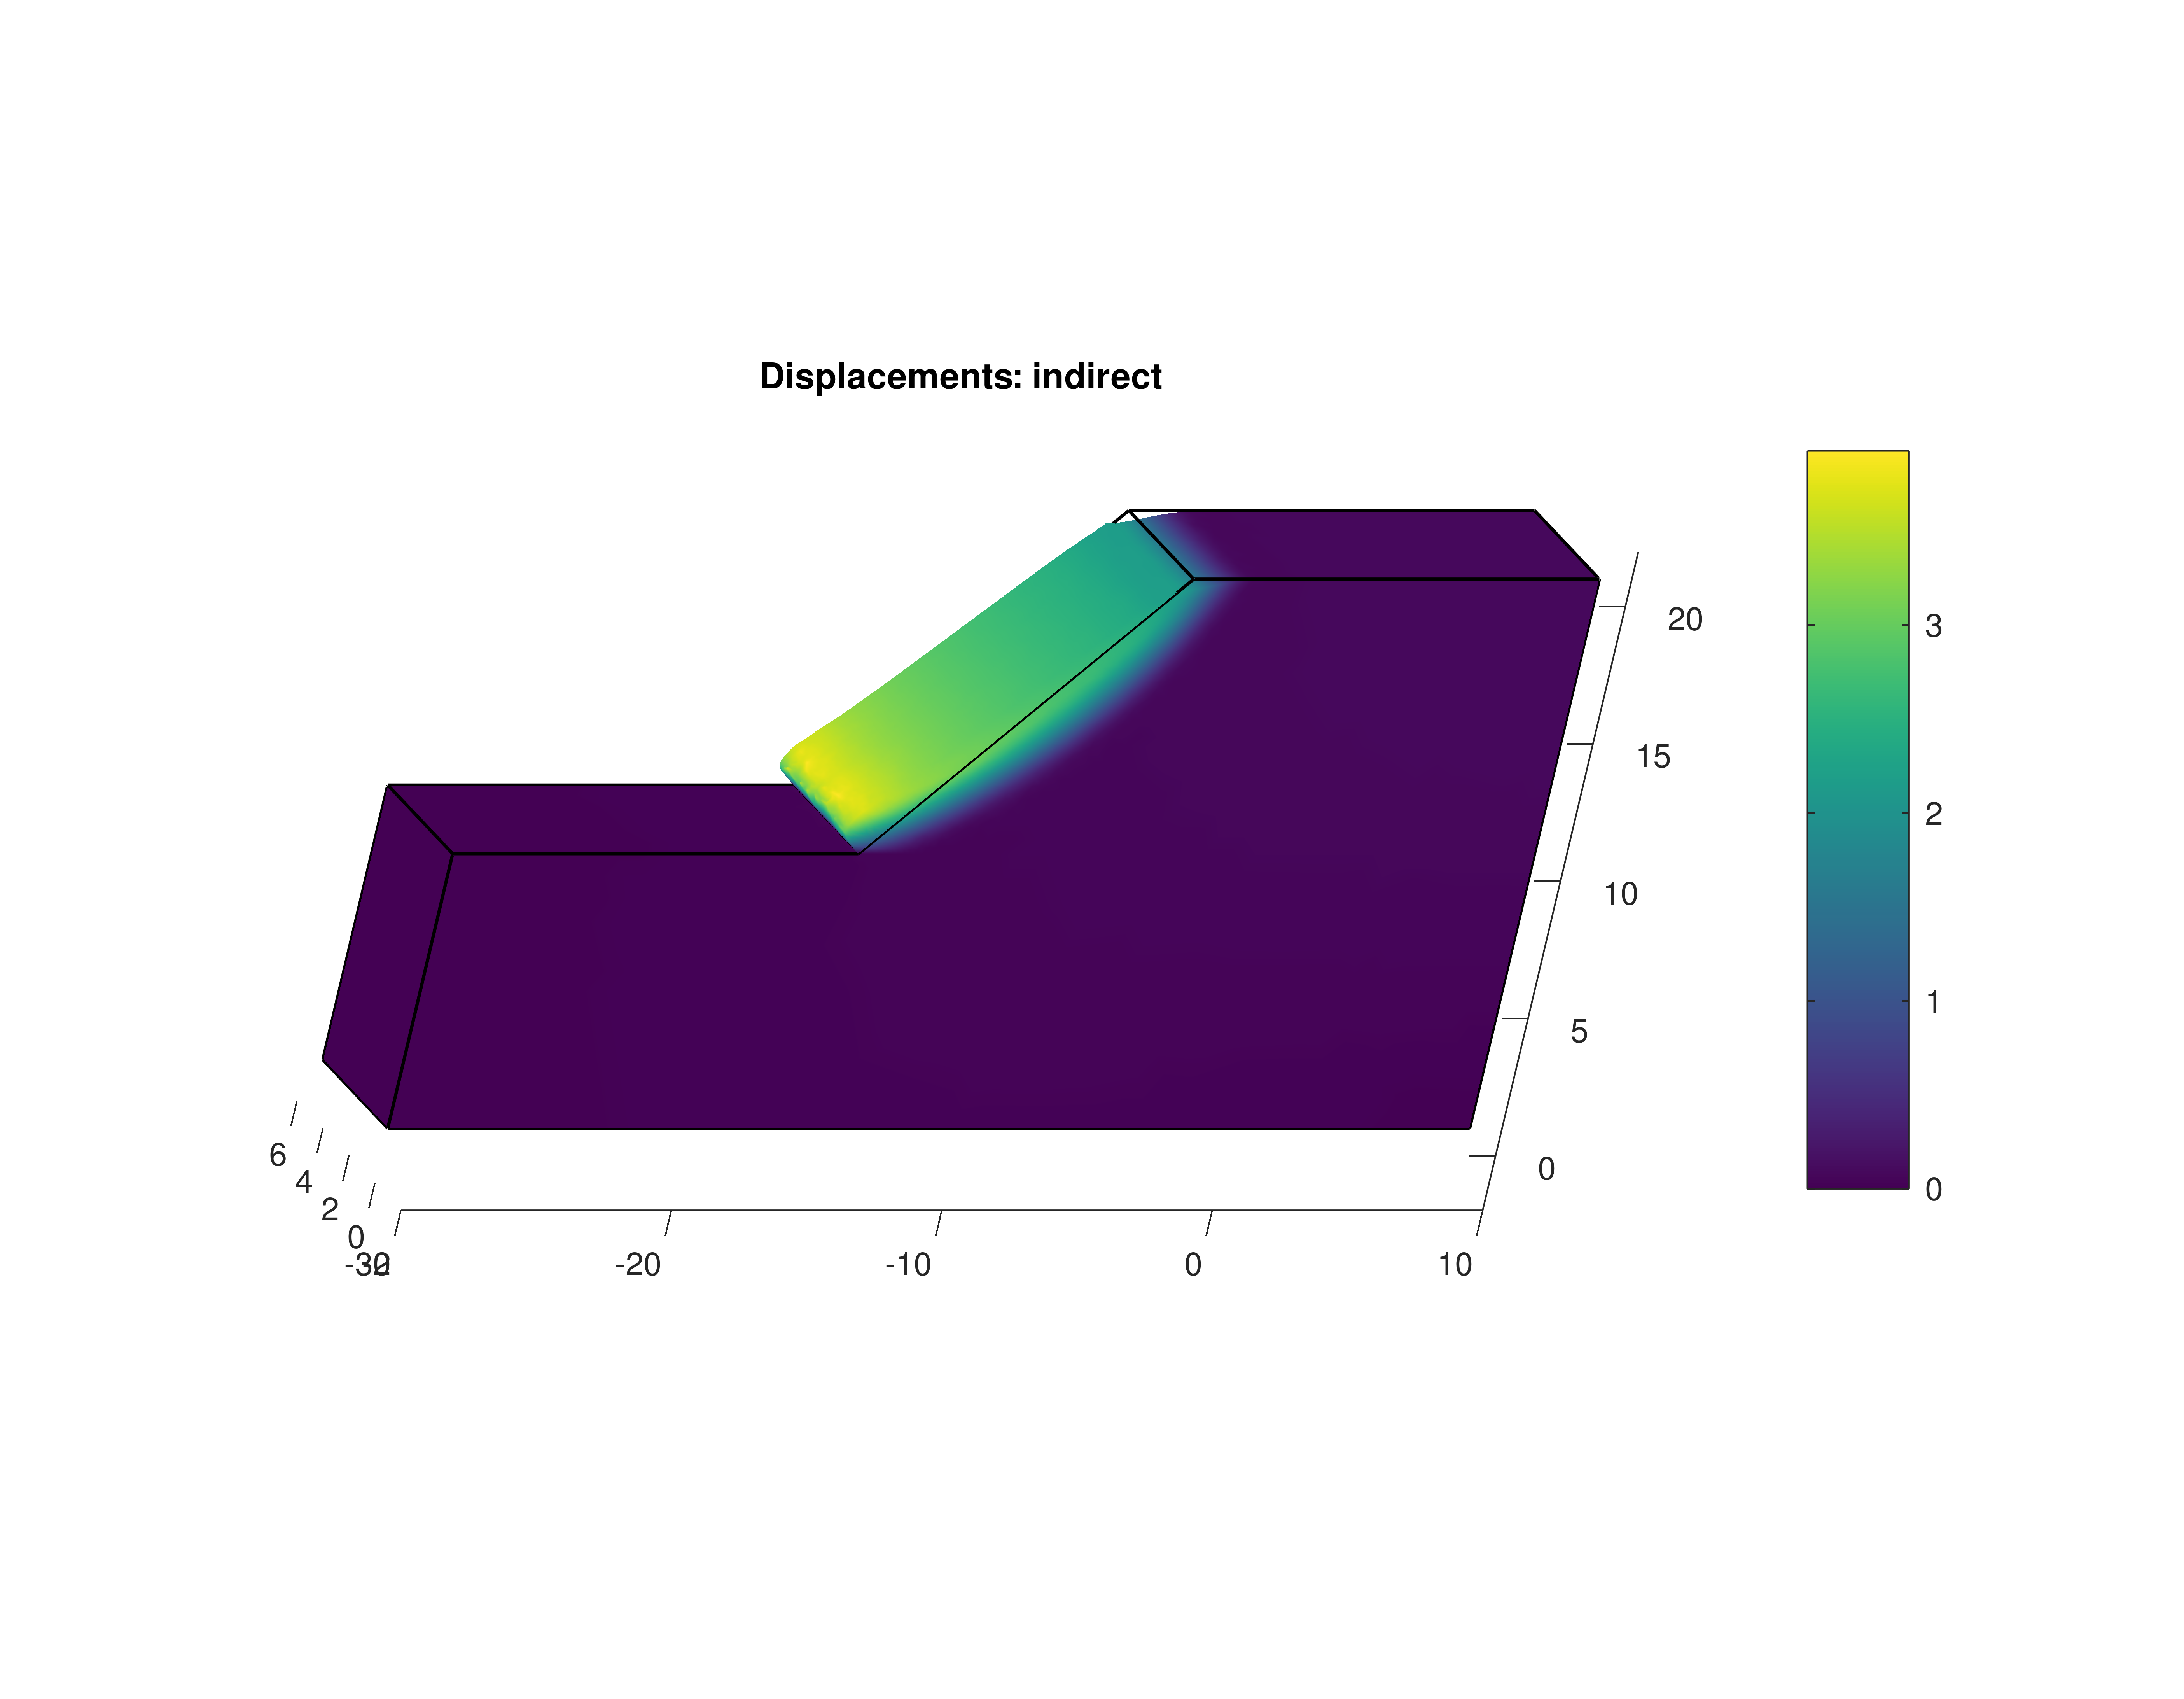

In [10]:
% Register computed solutions.
if direct_on
    plotter.add_solution('direct', U2, lambda_hist2, omega_hist2, Umax_hist2);
end
if indirect_on
    plotter.add_solution('indirect', U3, lambda_hist3, omega_hist3, Umax_hist3);
end

% Mechanical field plots.
plotter.plot_displacements();
drawnow; pause(0.2);

plotter.plot_deviatoric_strain(0.25);
drawnow; pause(0.2);

plotter.plot_convergence();

fprintf('Notebook workflow completed.\n');
